EEG Analysis Project: A Study of Auditory Lateralization
Author: Ismaïl-Ayoub EL GOTE
Date: 18 Feb 2026
Course / Context: X Reality and Psychology 2


1. Introduction
Electroencephalography (EEG) allows for the measurement of cerebral electrical activity with millisecond temporal resolution. This project aims to analyze brain responses evoked by auditory stimuli presented binaurally (left ear vs. right ear).

1.1 Scientific Objectives
The primary objective is to highlight the phenomenon of hemispheric lateralization in auditory processing.

1.2 Hypotheses
Time Domain (ERP): We expect to observe a prominent N100 component (negativity around 100ms) over temporal and central electrodes.

Topography (Lateralization): Consistent with the organization of auditory pathways, stimulation to the left ear should elicit a predominant cortical response in the right hemisphere (contralateral), and vice versa.

Time-Frequency Domain: We anticipate an increase in spectral power in lower frequencies (< 15 Hz) synchronized with stimulus onset (evoked and induced activity).

In [3]:
# Import libraries
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

#Set visualization parameters
%matplotlib inline

2. Data Loading and Configuration
We will use the MNE Sample Dataset, which contains multimodal (MEG/EEG) recordings from a passive audiovisual stimulation task.

2.1 Selection Strategy
To simulate a standard clinical acquisition, we will restrict the analysis to:

EEG channels (60 electrodes, standard 10-20 montage).

EOG (Electrooculogram) channels for artifact correction.

MEG channels (Magnetometers and Gradiometers) will be excluded

In [6]:
# --- CONFIGURATION PATHS ---
# Define data paths dynamically using MNE's built-in dataset function
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

# --- DATA LOADING ---
# Load raw data with preload=True to allow future processing
print("Loading data...")
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True, verbose=False)

# --- CHANNEL SELECTION ---
# Keep only EEG, EOG (for artifacts), and Stimulus channels
# We explicitly exclude MEG channels to simulate a standard EEG setup
raw.pick_types(meg=False, eeg=True, eog=True, stim=True)

# --- DISPLAY INFO ---
print("\n--- Data Information ---")
print(raw.info)
print(f"\nDimensions: {len(raw.ch_names)} channels x {raw.n_times} time points")
print(f"Sampling Frequency: {raw.info['sfreq']} Hz")

Loading data...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Data Information ---
<Info | 19 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: []
 ch_names: STI 001, STI 002, STI 003, STI 004, STI 005, STI 006, STI 014, ...
 chs: 9 Stimulus, 59 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 69
 proj_id: 1
 proj_name: test
 projs: []
 sfreq: 600.6 Hz
>

Dimensions: 69 channels x 166800 time points
Sampling Frequency: 600.614990234375 Hz


3. Signal Preprocessing
The quality of raw data necessitates rigorous cleaning to isolate brain activity from physiological and environmental noise.

3.1 Frequency Filtering and Re-referencing
We will apply the following filters:

High-pass filter: To eliminate slow drifts (sweat, slow movements).

Low-pass filter: To remove high-frequency noise while preserving the Gamma band for time-frequency analysis.

Notch filter: To suppress power line noise.

Re-referencing: The data will be re-referenced to an Average Reference, a current standard to minimize the bias of a single physical reference electrode.

In [7]:
# --- FILTER PARAMETERS ---
# Methodology:
# - HP 0.1 Hz: Preserves slow cognitive components (e.g., P300, CNV).
# - LP 100 Hz: Removes high-freq noise but keeps Gamma band (30-50Hz) for TFR.
# - Notch 60 Hz: Removes power line noise (specific to US datasets).
l_freq = 0.1
h_freq = 100.0
notch_freq = 60.0

# --- APPLY FILTERS ---
print(f"Applying filters (HP: {l_freq}Hz, LP: {h_freq}Hz, Notch: {notch_freq}Hz)...")

# Apply Band-pass filter (High-pass + Low-pass)
# n_jobs=-1 uses all available CPU cores for speed
raw.filter(l_freq=l_freq, h_freq=h_freq, n_jobs=-1, verbose=False)

# Apply Notch filter
raw.notch_filter(freqs=notch_freq, n_jobs=-1, verbose=False)

# --- RE-REFERENCING ---
print("Setting EEG reference to 'average' (Projection mode)...")

# We use projection=True. This adds a projector to the data structure 
# instead of modifying the data matrix immediately.
raw.set_eeg_reference('average', projection=True, verbose=False)

# Apply the projection immediately so that ICA (next step) uses referenced data
raw.apply_proj()

print("Preprocessing complete.")
print(f"New Low-pass cut-off: {raw.info['lowpass']} Hz")

Applying filters (HP: 0.1Hz, LP: 100.0Hz, Notch: 60.0Hz)...
Setting EEG reference to 'average' (Projection mode)...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Preprocessing complete.
New Low-pass cut-off: 100.0 Hz


3.2 Artifact Correction using ICA (Independent Component Analysis)
ICA is used to statistically separate signal sources.

Methodological Strategy:
As ICA is sensitive to low-frequency drifts, we will adopt a two-pass strategy:

Calculate (Fit) ICA on a copy of the data severely filtered (e.g., 1.0 Hz).

Apply the demixing matrix to the analysis data (e.g., filtered at 0.1 Hz).

This allows for robust detection of eye blinks (EOG) without altering slow cognitive components (such as P300 or CNV).

In [8]:
from mne.preprocessing import ICA

# --- ICA CONFIGURATION ---
# We use a 1.0 Hz High-pass filtered copy for the ICA fit.
# ICA is sensitive to low-frequency drifts; this ensures a stable decomposition.
print("Creating 1.0 Hz high-pass filtered copy for ICA stability...")
raw_ica_fit = raw.copy().filter(l_freq=1.0, h_freq=None, n_jobs=-1, verbose=False)

# Define ICA parameters
# n_components=15: Sufficient to isolate blinks and major artifacts
# method='picard': A more robust algorithm (or 'fastica')
ica = ICA(n_components=15, method='picard', random_state=97, max_iter='auto')

# --- ICA FITTING ---
print("Fitting ICA (this may take a few seconds)...")
ica.fit(raw_ica_fit, verbose=False)

# --- ARTIFACT DETECTION (EOG) ---
# Automatically find components correlating with the EOG channel ('EOG 061')
eog_indices, eog_scores = ica.find_bads_eog(raw_ica_fit, ch_name='EOG 061', verbose=False)

# Set the exclusion list
ica.exclude = eog_indices

print(f"ICA Fit complete.")
print(f"Detected EOG artifacts (blinks) at component indices: {eog_indices}")

# --- APPLY ICA ---
# We apply the solution calculated on the copy to the ORIGINAL 'raw' (0.1 Hz)
print("Applying ICA solution to the main data...")
ica.apply(raw, verbose=False)

# Clean up memory
del raw_ica_fit
print("Artifact correction complete.")

Creating 1.0 Hz high-pass filtered copy for ICA stability...
Fitting ICA (this may take a few seconds)...
ICA Fit complete.
Detected EOG artifacts (blinks) at component indices: [np.int64(0)]
Applying ICA solution to the main data...
Artifact correction complete.


4. Epoch Extraction
We segment the continuous signal around events of interest.

4.1 Condition Definition
We will focus on the auditory contrast:

Condition A: Auditory Stimulus / Left Ear

Condition B: Auditory Stimulus / Right Ear

4.2 Time Windowing
The analysis window is defined broadly (e.g., -0.5s to +1.0s) for two reasons:

To observe the pre-stimulus baseline.

To avoid edge effects during the Wavelet Transform in the next step.

In [9]:
# --- EVENT DETECTION ---
print("Finding events...")
# 'STI 014' is the standard trigger channel in this dataset
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)


# --- EVENT DICTIONARY ---
# We map the integer codes to descriptive labels.
# 1 = Auditory Left, 2 = Auditory Right.
# (We ignore Visual events 3 and 4 for this analysis).
event_id = {
    'Auditory/Left': 1,
    'Auditory/Right': 2
}


# --- EPOCHING PARAMETERS ---
# tmin/tmax: Wide window (-0.5s to 1.0s) is crucial for TFR analysis
# to avoid edge effects (cone of influence) in low frequencies.
tmin, tmax = -0.5, 1.0

# Baseline correction: (-0.2, 0) standard for ERPs.
baseline = (-0.2, 0)

# Rejection threshold: Drop epochs where peak-to-peak amplitude > 150 µV
# (This catches massive movement artifacts that ICA couldn't fix)
reject = dict(eeg=150e-6)


# --- CREATE EPOCHS ---
print(f"Creating epochs (Window: {tmin}s to {tmax}s)...")
epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=baseline,
    reject=reject,
    preload=True,
    verbose=False
)

print("Epoching complete.")
print(epochs)
# Display how many epochs were dropped due to the rejection threshold
print(f"Dropped epochs stats: {epochs.drop_log_stats()}")

Finding events...
Creating epochs (Window: -0.5s to 1.0s)...
Epoching complete.
<Epochs | 141 events (all good), -0.499 – 1.001 s (baseline -0.2 – 0 s), ~69.9 MiB, data loaded,
 'Auditory/Left': 70
 'Auditory/Right': 71>
Dropped epochs stats: 2.7586206896551726


5. Time-Frequency Analysis (1-50 Hz)
This step aims to quantify the oscillatory energy of the signal between 1 and 50 Hz.

5.1 Methodology: Morlet Wavelets
We use Morlet wavelet convolution to obtain a time-frequency representation.

Adaptive Cycles: The number of cycles will increase with frequency to optimize the trade-off between temporal resolution (low frequencies) and frequency resolution (high frequencies).

Normalization: A spectral baseline correction (Log-Ratio dB) will be applied to highlight relative power changes compared to the pre-stimulus silence.

Computing Morlet Wavelets (1-50 Hz)...
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Plotting Time-Frequency representation...
Applying baseline correction (mode: logratio)


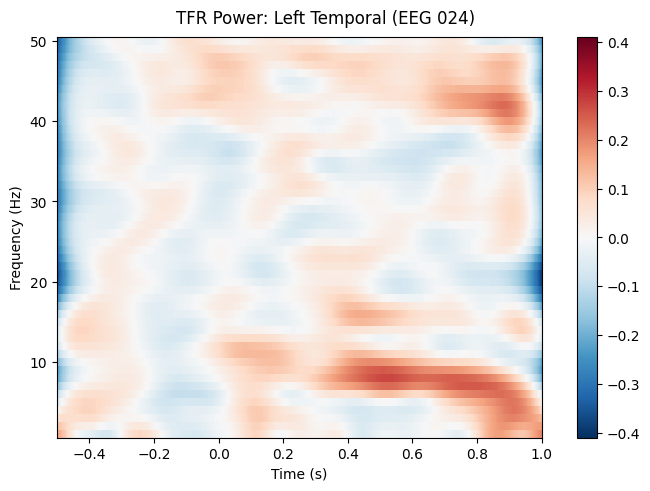

[<Figure size 640x480 with 2 Axes>]

In [10]:
# --- TFR PARAMETERS ---
# Frequencies: 1 to 50 Hz (Standard range for EEG)
freqs = np.arange(1, 51, 1)

# Adaptive cycles: 
# Low freq (e.g., 2Hz) -> 1 cycle (High temporal resolution)
# High freq (e.g., 50Hz) -> 25 cycles (High frequency resolution)
n_cycles = freqs / 2.0


# --- COMPUTE TFR ---
print("Computing Morlet Wavelets (1-50 Hz)...")

# We compute power on 'Auditory' epochs (combining Left and Right)
# to see the general auditory response.
power = mne.time_frequency.tfr_morlet(
    epochs['Auditory'],
    freqs=freqs,
    n_cycles=n_cycles,
    use_fft=True,
    return_itc=False, # Focus on Power, not Phase Consistency
    average=True,     # Average over epochs
    n_jobs=-1,
    verbose=False
)

# --- VISUALIZATION ---
print("Plotting Time-Frequency representation...")

# We pick 'EEG 024' (approx. Left Temporal area in this montage)
# Baseline mode='logratio' converts power to decibels (dB) relative to baseline.
power.plot(
    picks=['EEG 024'],
    baseline=(-0.4, -0.1), 
    mode='logratio', 
    title='TFR Power: Left Temporal (EEG 024)',
    combine='mean'
)

6. Estimation of Evoked Responses (ERP)
The analysis of Event-Related Potentials (ERPs) allows for isolating the "phase-locked" response (perfectly synchronized to the stimulus) through averaging.

We will specifically look for the N100 component (early auditory response).

Computing Evoked Responses (Averaging epochs)...
Evoked Left created (70 trials averaged)
Evoked Right created (71 trials averaged)
Plotting Butterfly plot to identify main peaks...


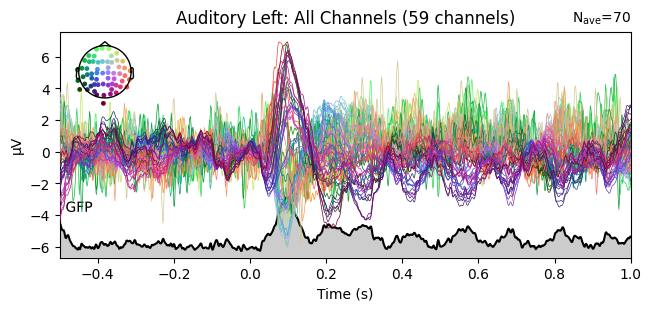

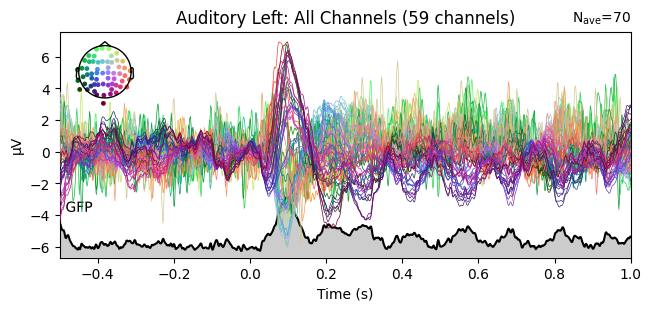

In [11]:
# --- AVERAGING ---
print("Computing Evoked Responses (Averaging epochs)...")
# Average the epochs separately for Left and Right conditions
evoked_left = epochs['Auditory/Left'].average()
evoked_right = epochs['Auditory/Right'].average()

# .nave gives the number of averaged epochs (should be ~70)
print(f"Evoked Left created ({evoked_left.nave} trials averaged)")
print(f"Evoked Right created ({evoked_right.nave} trials averaged)")


# --- VISUALIZATION (Butterfly Plot) ---
print("Plotting Butterfly plot to identify main peaks...")

# A "Butterfly plot" superimposes all channels.
# The black line represents the Global Field Power (GFP).
# We clearly expect a peak around 100ms (N100) and 200ms (P200).
evoked_left.plot(
    spatial_colors=True, # Colors indicate electrode position
    gfp=True,            # Show Global Field Power
    titles={'eeg': 'Auditory Left: All Channels'},
    time_unit='s'
)

7. Results: Lateralization Analysis
This section forms the core of the scientific demonstration. We will compare the topography of brain responses based on the side of stimulation.

7.1 Topographical Maps (Topomaps)
Visual comparison of the spatial distribution of voltage at the N100 peak (~100ms).

In [ ]:
# --- TOPOMAP PARAMETERS ---
# We focus on the N100 peak identified in the previous plot (approx 100ms)
times = [0.1]  # 0.1 seconds = 100 ms

--- PLOT TOPOMAPS ---

Display Topomaps for Left vs Right stimulation side-by-side

7.2 Region of Interest (ROI) Comparison
To statistically validate the effect, we compare the signal amplitude on symmetrical electrode groups (Left Temporal vs. Right Temporal).

Expected Outcome: The N100 amplitude should be maximal over the ROI contralateral to the stimulus.

In [ ]:
--- ROI DEFINITION ---

Define lists of channels for Left Temporal and Right Temporal ROIs

--- ROI PLOTTING ---

Plot comparison of Evoked responses specifically on these ROIs

8. Discussion and Conclusion
(To be drafted after analysis)

This section will summarize:

The validation (or refutation) of the initial hypotheses regarding the N100 and lateralization.

The interpretation of observed oscillatory dynamics (TFR).

The methodological limitations of the study (e.g., average reference, volume conduction).

Perspectives for future improvements.